Loading Checkpoint & Prior...
Successfully loaded means for 2 attributes.
Generating visualizations...


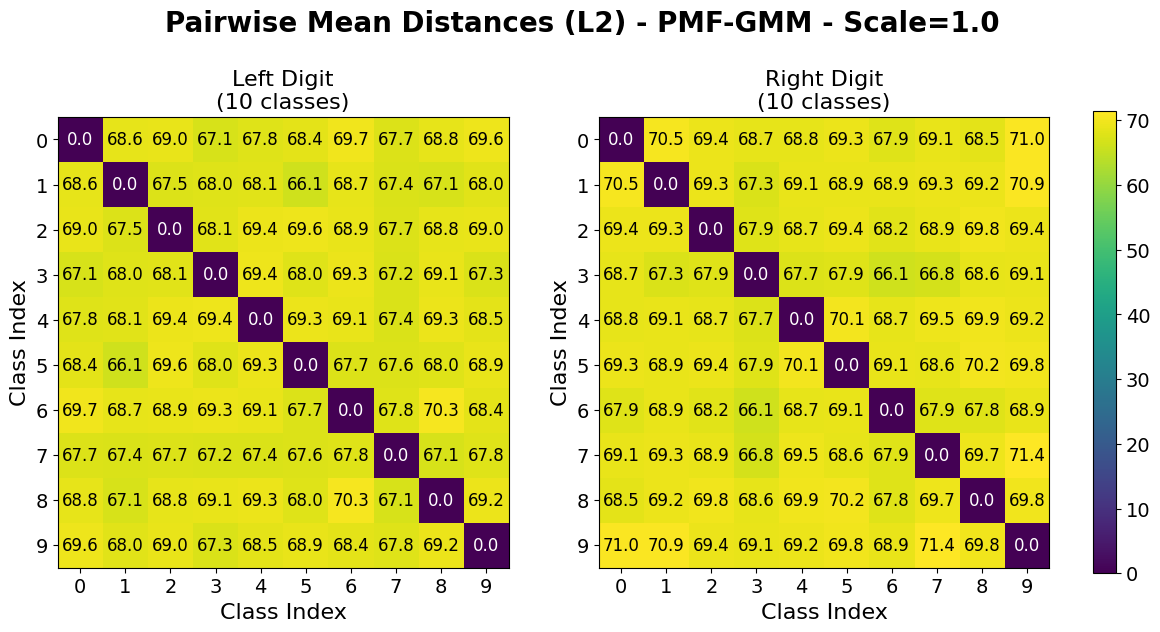

In [1]:
import os
import sys
import torch
import importlib
import argparse
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..', '..')))
sys.path.append(os.path.abspath(os.path.join('..', 'priors')))
sys.path.append(os.path.abspath(os.path.join('..', 'models')))
from CheckerboardGMM import CheckerboardGMM

VERSION = "2_attr"
SCALE = 1.0

if VERSION == '1_attr':
    ARR_NUM_CLASSES = [10]
elif VERSION == '2_attr':
    ARR_NUM_CLASSES = [10, 10]
elif VERSION == '3_attr':
    ARR_NUM_CLASSES = [10, 10, 7]
elif VERSION == '4_attr':
    ARR_NUM_CLASSES = [10, 10, 7, 7]
else:
    raise ValueError(f"Unknown VERSION: {VERSION}")

NUM_ATTR = len(ARR_NUM_CLASSES)

MODEL_CONFIG = {
    "MODEL": "hybrid_v3_1x1_double", 
    "PATH": f"../experiments/models/GMM/{VERSION}/best_loss_{SCALE}_hybrid_v3_1x1_double_CheckerboardGMM_Adam_0.5_0.1.pth",
    "PRIOR": "CheckerboardGMM",
    "TOTAL_DIM": 4704 
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PLOT_DIR = f"plots/GMM_{SCALE}_{VERSION}/mean_distances/"
os.makedirs(PLOT_DIR, exist_ok=True)

def plot_means_distance_matrices(prior, save_dir, metric='l2'):
    num_attrs = len(prior.means)

    dist_matrices = []

    for means in prior.means:
        if metric == 'l2':
            dist_matrix = torch.cdist(means, means, p=2).cpu().numpy()
        elif metric == 'squared_l2':
            dist_matrix = torch.cdist(means, means, p=2).pow(2).cpu().numpy()
        elif metric == 'cosine':
            norm_means = torch.nn.functional.normalize(means, p=2, dim=1)
            sim_matrix = torch.mm(norm_means, norm_means.t())
            dist_matrix = (1 - sim_matrix).cpu().numpy()
        else:
            raise ValueError(f"Unknown metric {metric}")

        dist_matrices.append(dist_matrix)

    vmin = min(dm.min() for dm in dist_matrices)
    vmax = max(dm.max() for dm in dist_matrices)

    fig, axes = plt.subplots(1, num_attrs, figsize=(7 * num_attrs, 6))
    if num_attrs == 1:
        axes = [axes]

    fig.suptitle(
        f"Pairwise Mean Distances ({metric.upper()}) - PMF-GMM - Scale={SCALE}",
        fontsize=20,
        fontweight='bold',
        y=1.05
    )

    im = None

    for i, dist_matrix in enumerate(dist_matrices):
        ax = axes[i]

        im = ax.imshow(
            dist_matrix,
            cmap='viridis',
            vmin=vmin,
            vmax=vmax
        )

        num_classes = dist_matrix.shape[0]
        ax.set_xticks(np.arange(num_classes))
        ax.set_yticks(np.arange(num_classes))

        if i == 0:
            title_string = "Left Digit"
        elif i == 1:
            title_string = "Right Digit"
        else:
            title_string = f"Attribute {i}"

        ax.set_title(f"{title_string}\n({num_classes} classes)", fontsize=16)
        ax.set_xlabel("Class Index", fontsize=16)
        ax.set_ylabel("Class Index", fontsize=16)
        ax.tick_params(axis='both', labelsize=14)

        threshold = vmax / 2.0

        for row in range(num_classes):
            for col in range(num_classes):
                val = dist_matrix[row, col]
                color = "white" if val < threshold else "black"
                ax.text(
                    col,
                    row,
                    f"{val:.1f}",
                    ha="center",
                    va="center",
                    color=color,
                    fontsize=12
                )

    cb = fig.colorbar(
        im,
        ax=axes,
        fraction=0.046,
        pad=0.04
    )
    cb.ax.tick_params(labelsize=14)

    # plt.tight_layout()
    plt.show()
    plt.close(fig)

if __name__ == "__main__":
    print("Loading Checkpoint & Prior...")
    
    prior_class = globals()[MODEL_CONFIG['PRIOR']]
    prior = prior_class(
        total_dim=MODEL_CONFIG['TOTAL_DIM'], 
        arr_num_classes=ARR_NUM_CLASSES, 
        device=DEVICE, 
        scale=SCALE, 
        fixed_means=True
    )
    
    checkpoint = torch.load(MODEL_CONFIG['PATH'], map_location=DEVICE)
    
    prior.load_state_dict(checkpoint['prior_state_dict'])
    prior.means = checkpoint['means']
    prior.means = [m.detach() for m in prior.means]
    
    print(f"Successfully loaded means for {NUM_ATTR} attributes.")
    print("Generating visualizations...")
    
    plot_means_distance_matrices(prior, PLOT_DIR, metric='l2')

--- Evaluating for BETA = 0.01 ---


Successfully loaded means for 2 attributes.


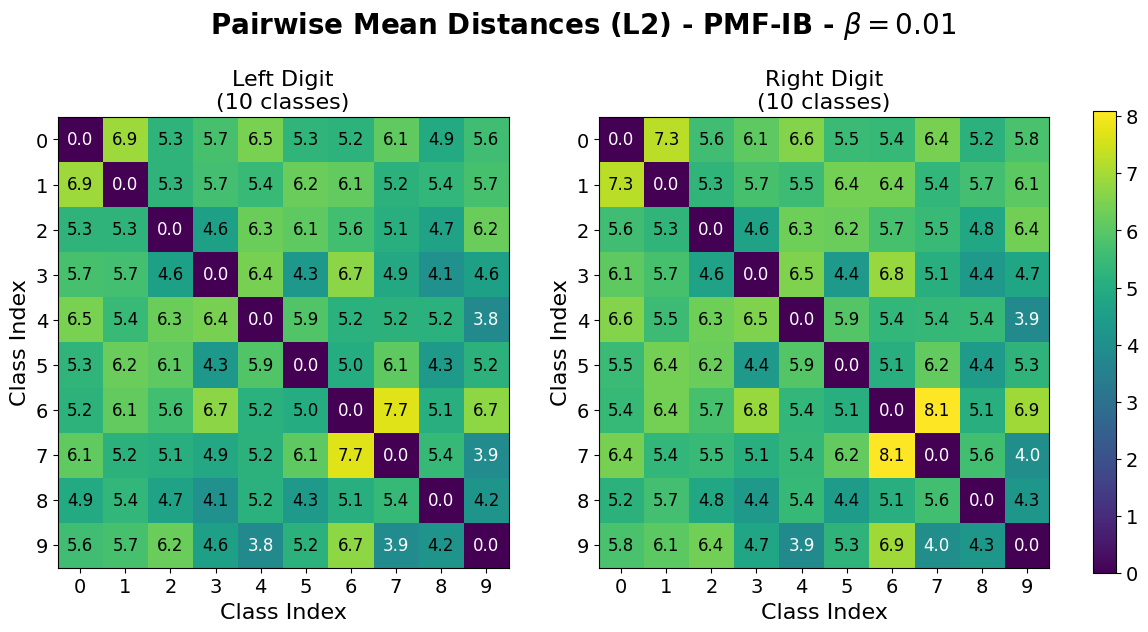

--- Evaluating for BETA = 0.05 ---
Successfully loaded means for 2 attributes.


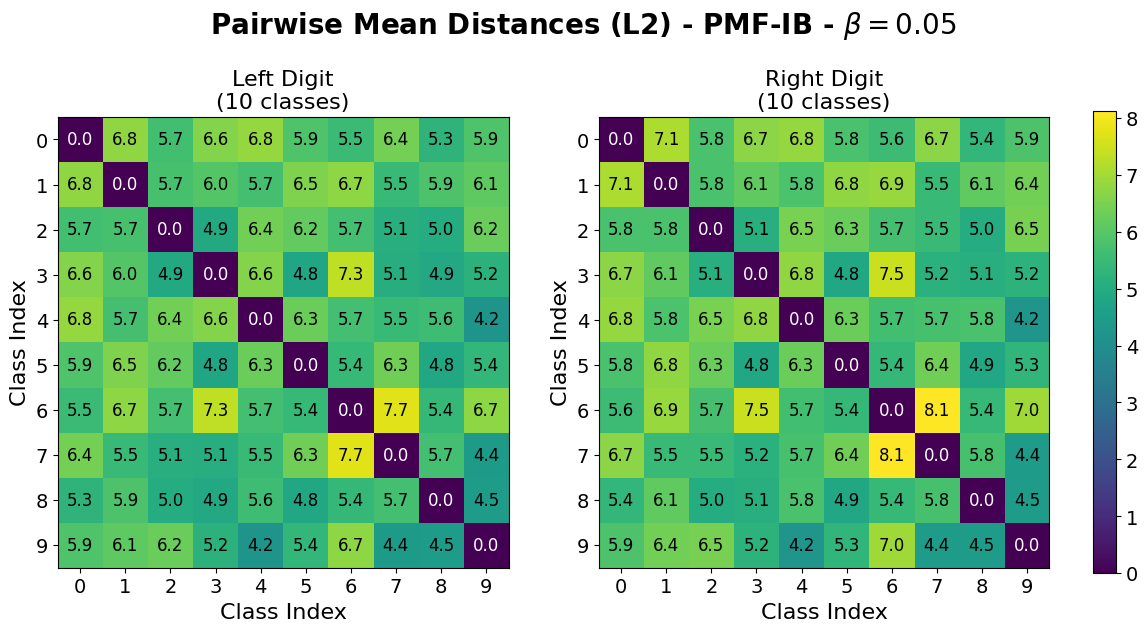

--- Evaluating for BETA = 0.1 ---
Successfully loaded means for 2 attributes.


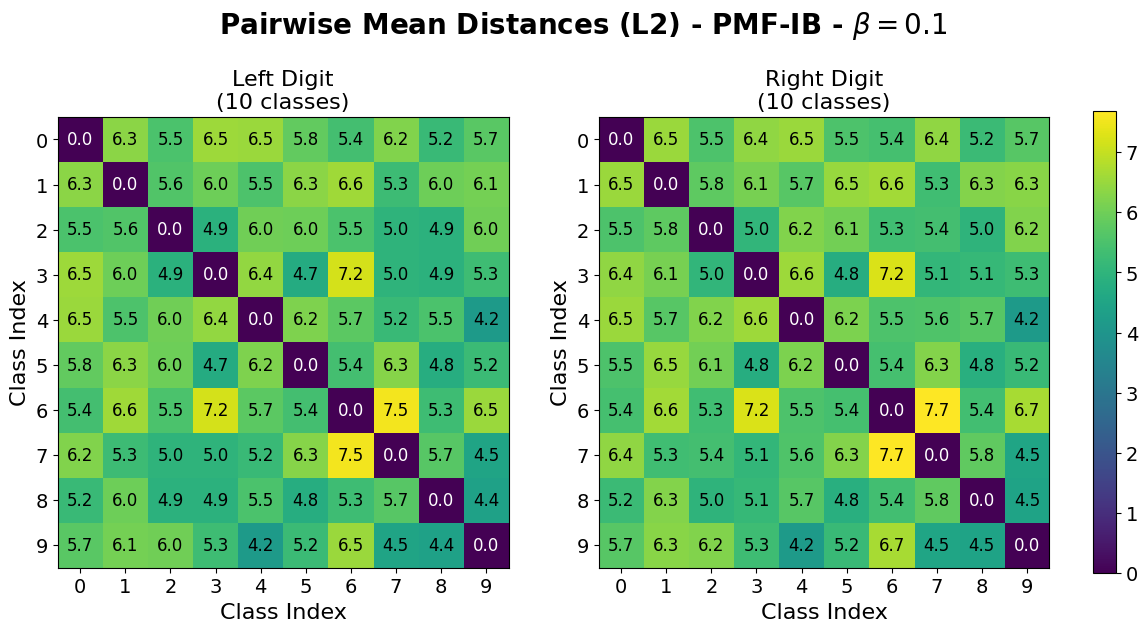

--- Evaluating for BETA = 0.5 ---
Successfully loaded means for 2 attributes.


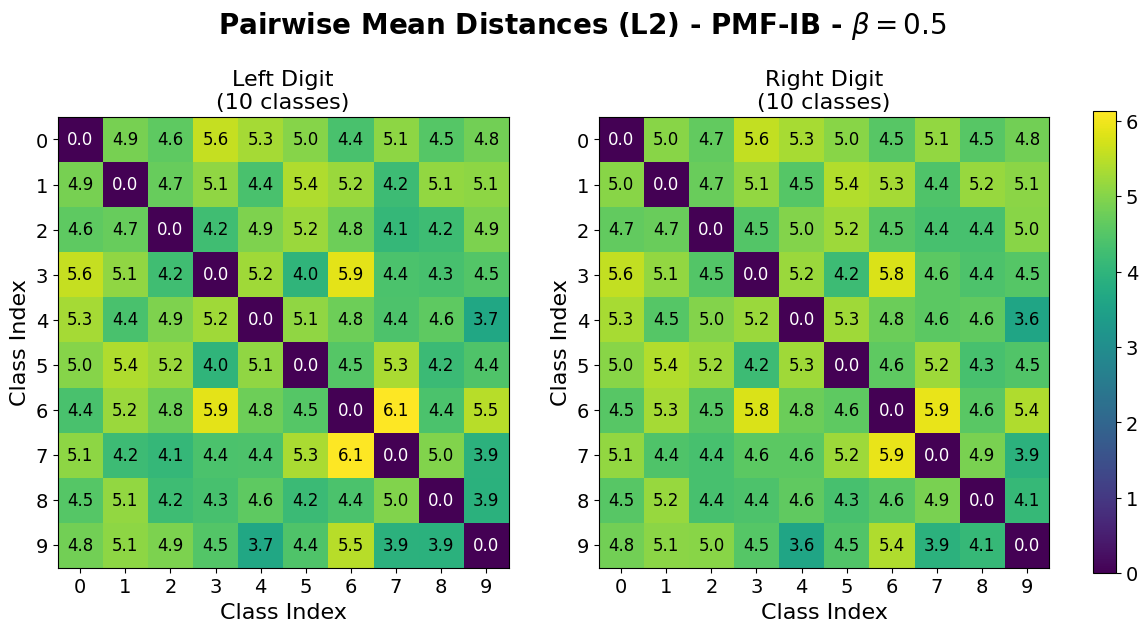

--- Evaluating for BETA = 1.0 ---
Successfully loaded means for 2 attributes.


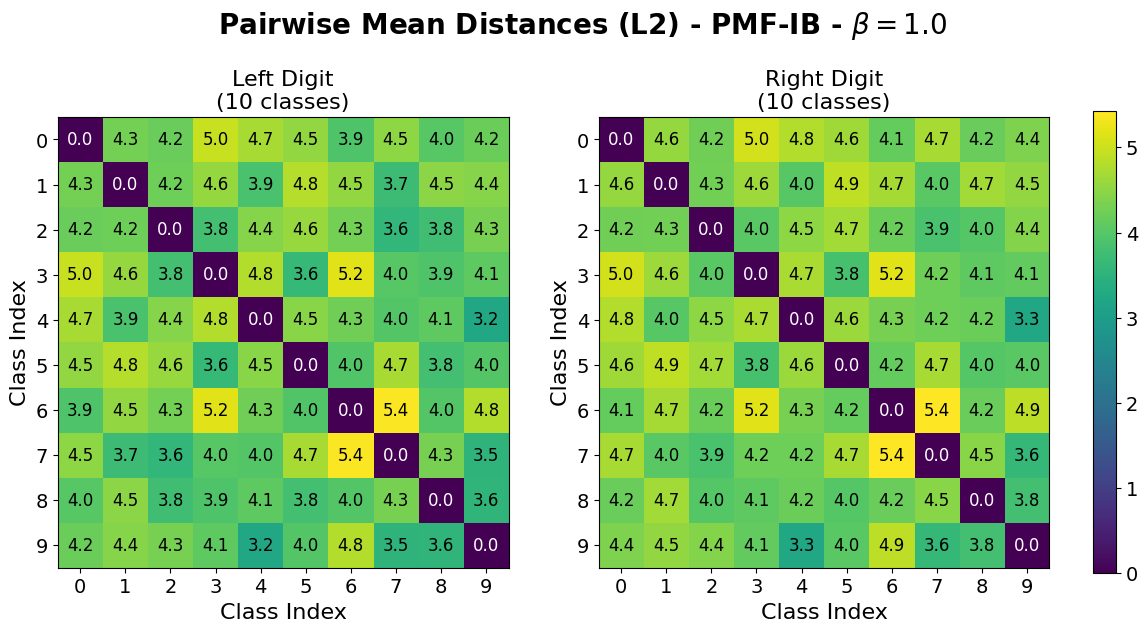

--- Evaluating for BETA = 2.0 ---
Successfully loaded means for 2 attributes.


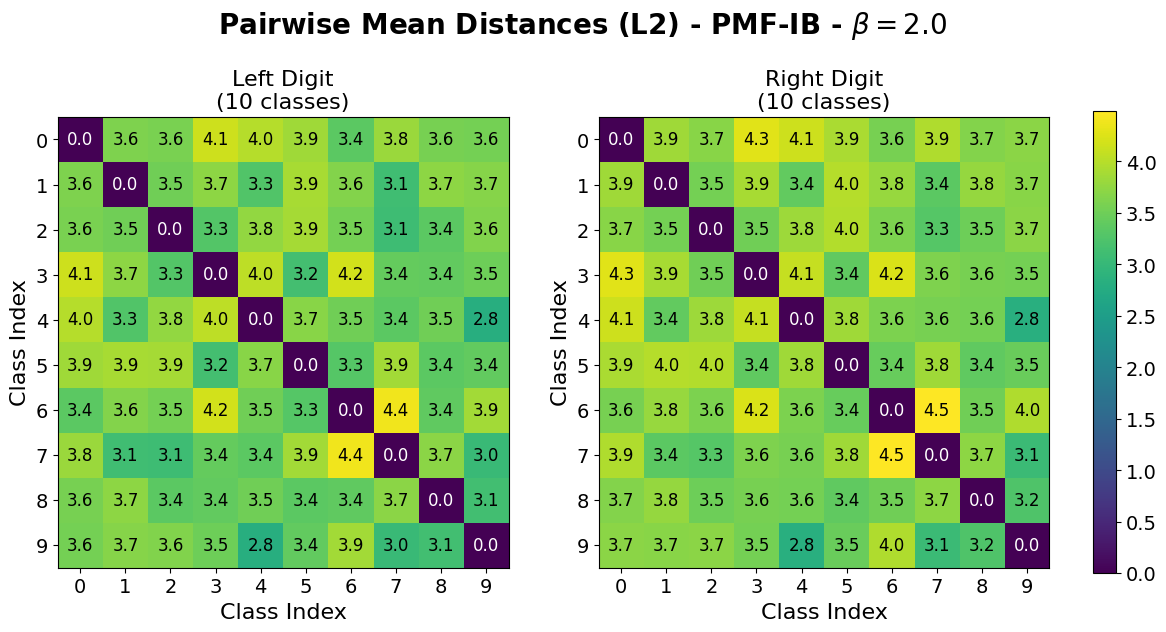

In [2]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..', '..')))
sys.path.append(os.path.abspath(os.path.join('..', 'priors')))
sys.path.append(os.path.abspath(os.path.join('..', 'models')))
from CheckerboardIB import CheckerboardIB

VERSION = "2_attr"

if VERSION == '1_attr':
    ARR_NUM_CLASSES = [10]
elif VERSION == '2_attr':
    ARR_NUM_CLASSES = [10, 10]
elif VERSION == '3_attr':
    ARR_NUM_CLASSES = [10, 10, 7]
elif VERSION == '4_attr':
    ARR_NUM_CLASSES = [10, 10, 7, 7]
else:
    raise ValueError(f"Unknown VERSION: {VERSION}")

NUM_ATTR = len(ARR_NUM_CLASSES)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def plot_means_distance_matrices(prior, beta, metric='l2'):
    """
    Plots distance matrices for the means of each attribute in a shared grid.
    """
    num_attrs = len(prior.means)
    fig, axes = plt.subplots(1, num_attrs, figsize=(7 * num_attrs, 6))
    if num_attrs == 1:
        axes = [axes]
        
    fig.suptitle(
        f"Pairwise Mean Distances ({metric.upper()}) - PMF-IB - $\\beta={beta}$",
        fontsize=20,
        fontweight='bold',
        y=1.05
    )

    dist_matrices = []
    for means_param in prior.means:
        means = means_param.detach()

        if metric == 'l2':
            dist_matrix = torch.cdist(means, means, p=2).cpu().numpy()
        elif metric == 'squared_l2':
            dist_matrix = torch.cdist(means, means, p=2).pow(2).cpu().numpy()
        elif metric == 'cosine':
            norm_means = torch.nn.functional.normalize(means, p=2, dim=1)
            sim_matrix = torch.mm(norm_means, norm_means.t())
            dist_matrix = (1 - sim_matrix).cpu().numpy()
        else:
            raise ValueError(f"Unknown metric {metric}")

        dist_matrices.append(dist_matrix)

    vmin = min(d.min() for d in dist_matrices)
    vmax = max(d.max() for d in dist_matrices)

    im = None

    for i, dist_matrix in enumerate(dist_matrices):
        ax = axes[i]

        im = ax.imshow(dist_matrix, cmap='viridis', vmin=vmin, vmax=vmax)
        
        num_classes = dist_matrix.shape[0]
        ax.set_xticks(np.arange(num_classes))
        ax.set_yticks(np.arange(num_classes))
        
        if i == 0:
            title_string = "Left Digit"
        elif i == 1:
            title_string = "Right Digit"
        else:
            title_string = f"Attribute {i+1}"
            
        ax.set_title(f"{title_string}\n({num_classes} classes)", fontsize=16)
        ax.set_xlabel("Class Index", fontsize=16)
        ax.set_ylabel("Class Index", fontsize=16)
        ax.tick_params(axis='both', labelsize=14)
        
        threshold = vmax / 2.0
        for row in range(num_classes):
            for col in range(num_classes):
                val = dist_matrix[row, col]
                color = "white" if val < threshold else "black"
                ax.text(
                    col,
                    row,
                    f"{val:.1f}",
                    ha="center",
                    va="center",
                    color=color,
                    fontsize=12
                )

    cb = fig.colorbar(
        im,
        ax=axes,
        fraction=0.046,
        pad=0.04
    )
    cb.ax.tick_params(labelsize=14)
    # plt.tight_layout()
    plt.show()

def evaluate_beta(beta):
    """
    Loads the model checkpoint for a specific beta and plots the distance matrices inline.
    """
    print(f"--- Evaluating for BETA = {beta} ---")
    
    model_path = f"../experiments/models/IB/{VERSION}/best_loss_0.0_hybrid_v3_1x1_double_CheckerboardIB_{beta}_Adam_0.5_0.1_False_20_.pth"
    
    prior = CheckerboardIB(
        total_dim=4704, 
        arr_num_classes=ARR_NUM_CLASSES, 
        beta=beta,
        device=DEVICE, 
        scale=0.0, 
        fixed_means=False
    )
    
    try:
        checkpoint = torch.load(model_path, map_location=DEVICE)
        prior.load_state_dict(checkpoint['prior_state_dict'])
        print(f"Successfully loaded means for {NUM_ATTR} attributes.")
    except FileNotFoundError:
        print(f"Error: Could not find checkpoint at {model_path}")
        return
        
    plot_means_distance_matrices(prior, beta=beta, metric='l2')

evaluate_beta(beta=0.01)
evaluate_beta(beta=0.05)
evaluate_beta(beta=0.1)
evaluate_beta(beta=0.5)
evaluate_beta(beta=1.0)
evaluate_beta(beta=2.0)